# House Price Prediction — Machine Learning Notebook

**Project scope:** This notebook implements the **Notebook / Machine Learning phase** of the supplied Student Project Guide. The Backend and Frontend phases are intentionally excluded.

> **Note:** I have not worked on the Backend before, so this submission focuses on the data analysis, cleaning, feature engineering, model training, evaluation, comparison, and model export in the Jupyter Notebook.

> ****Note:**** I received guidance from AI with some advanced parts of the code


# 2.1 Load & Inspect

Load the supplied `house_prices.csv` dataset and inspect its shape, columns, data types, sample rows, and missing values. The guide explicitly says to verify the real columns from the downloaded file before building the pipeline.

In [5]:
import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.base import clone

DATA_PATH = r"C:\Users\CYBER-TECH\Downloads\house_prices.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.head()

Shape: (187531, 21)

Columns:
['Index', 'Title', 'Description', 'Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'Dimensions', 'Plot Area']


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [6]:
df.info()
df.describe()

print("\nMissing values (%):")
display((df.isna().mean().mul(100).sort_values(ascending=False)
         .to_frame("missing_percent")))

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

,missing_percent
Plot Area,100.000000
Dimensions,100.000000
Society,58.485264
Super Area,57.422506
Car Parking,55.114621
overlooking,43.425354
Carpet Area,43.018488
facing,37.451408
Ownership,34.936624
Balcony,26.094352


### Data Inspection

The dataset contains 187,531 rows and 21 columns. The main target for this project is `Amount(in rupees)`, which is stored as text and contains values such as Lac and Cr. `Price (in rupees)` is a numeric price-per-square-foot field in this dataset, so it is not used as the prediction target. Several descriptive columns have substantial missingness; the cleaning stage below handles the fields needed for modeling and drops columns that are not useful for this model.

## 2.2 Exploratory Data Analysis (EDA)

four plots: target-price distribution, price vs. carpet area, average price by top-15 locations, and price by furnishing status / number of bathrooms.

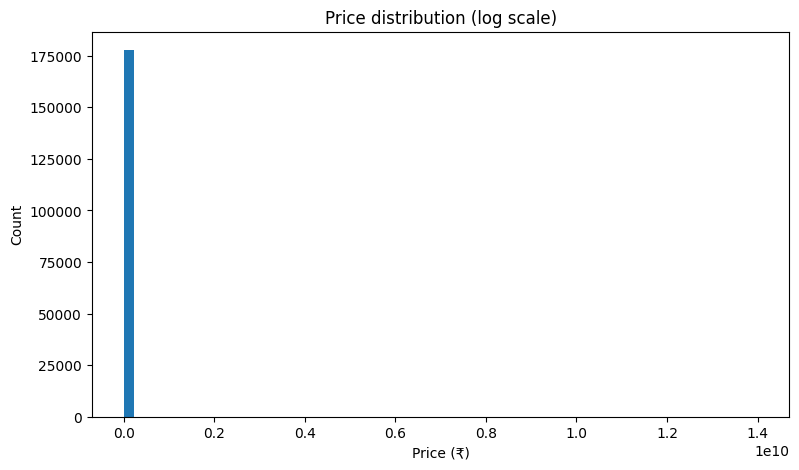

Comment: The target is strongly right-skewed, so a log-scaled x-axis makes the distribution easier to inspect.


In [7]:
# Convert the target first so the EDA uses a numeric price.
def parse_amount(x):
    if not isinstance(x, str):
        return np.nan
    x = x.strip().lower().replace(",", "")
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x)
    except ValueError:
        return np.nan

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

plt.figure(figsize=(9, 5))
plt.hist(df["price_clean"].dropna(), bins=60)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (₹)")
plt.ylabel("Count")
plt.show()

print("Comment: The target is strongly right-skewed, so a log-scaled x-axis makes the distribution easier to inspect.")

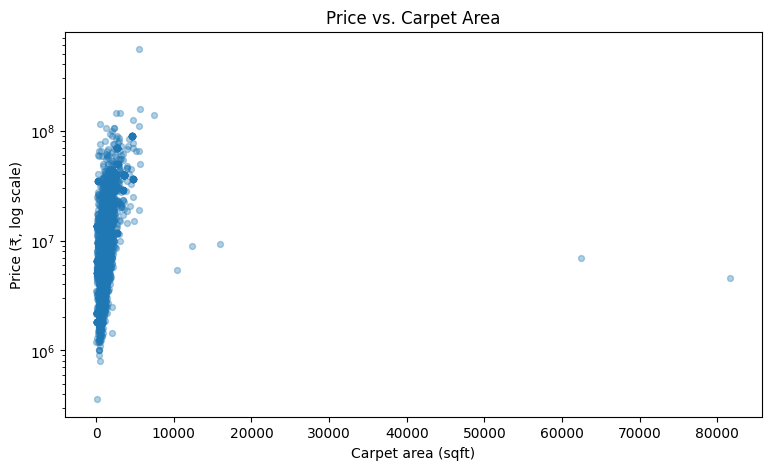

Comment: Larger carpet areas generally correspond to higher prices, although location and property characteristics create substantial variation.


In [8]:
def parse_area_to_sqft(x):
    if not isinstance(x, str):
        return np.nan
    s = x.strip().lower().replace(",", "")
    m = re.search(r"([0-9]+(?:\.[0-9]+)?)", s)
    if not m:
        return np.nan
    value = float(m.group(1))
    if "sqm" in s or "sq m" in s or "m2" in s:
        return value * 10.764
    return value

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area_to_sqft)

plot_df = df[["carpet_area_sqft", "price_clean"]].dropna()
plt.figure(figsize=(9, 5))
sample_plot = plot_df.sample(min(8000, len(plot_df)), random_state=42)
plt.scatter(sample_plot["carpet_area_sqft"], sample_plot["price_clean"], alpha=0.35, s=18)
plt.yscale("log")
plt.title("Price vs. Carpet Area")
plt.xlabel("Carpet area (sqft)")
plt.ylabel("Price (₹, log scale)")
plt.show()

print("Comment: Larger carpet areas generally correspond to higher prices, although location and property characteristics create substantial variation.")

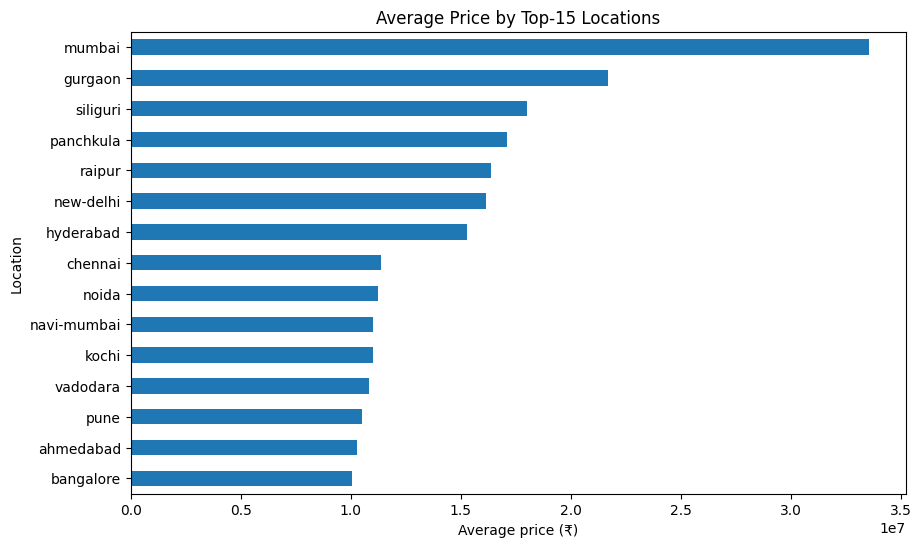

Comment: Average prices differ noticeably across locations, showing why location should be retained as a categorical predictor.


In [9]:
top15 = (df.groupby("location")["price_clean"]
          .mean()
          .nlargest(15)
          .sort_values())

plt.figure(figsize=(10, 6))
top15.plot(kind="barh")
plt.title("Average Price by Top-15 Locations")
plt.xlabel("Average price (₹)")
plt.ylabel("Location")
plt.show()

print("Comment: Average prices differ noticeably across locations, showing why location should be retained as a categorical predictor.")

<Figure size 900x500 with 0 Axes>

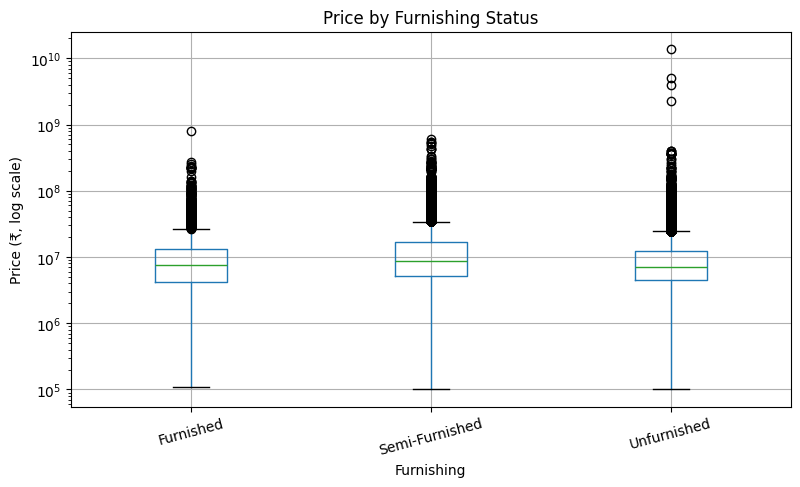

Comment: Price distributions vary across furnishing categories, suggesting furnishing status may contribute useful predictive information.


<Figure size 1000x500 with 0 Axes>

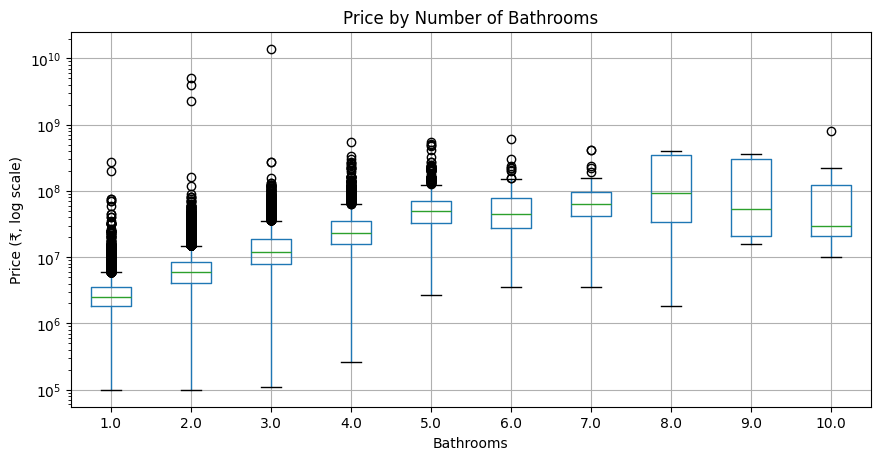

Comment: Properties with different bathroom counts show different price distributions; bathroom count is therefore included as a numeric feature.


In [10]:
eda_df = df.copy()
eda_df["bathroom_num"] = pd.to_numeric(eda_df["Bathroom"], errors="coerce")

plt.figure(figsize=(9, 5))
eda_df.boxplot(column="price_clean", by="Furnishing", figsize=(9,5))
plt.suptitle("")
plt.yscale("log")
plt.title("Price by Furnishing Status")
plt.xlabel("Furnishing")
plt.ylabel("Price (₹, log scale)")
plt.xticks(rotation=15)
plt.show()

print("Comment: Price distributions vary across furnishing categories, suggesting furnishing status may contribute useful predictive information.")

plt.figure(figsize=(10, 5))
eda_df.boxplot(column="price_clean", by="bathroom_num", figsize=(10,5))
plt.suptitle("")
plt.yscale("log")
plt.title("Price by Number of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Price (₹, log scale)")
plt.show()

print("Comment: Properties with different bathroom counts show different price distributions; bathroom count is therefore included as a numeric feature.")

## 2.3 Cleaning & Feature Engineering


- Convert `Amount(in rupees)` into a numeric price (`1 Lac = 100,000`, `1 Cr = 10,000,000`).
- Convert carpet area text into square feet; square metres are converted using `1 sqm ≈ 10.764 sqft`.
- Extract the numeric floor from values such as `3 out of 10`; `Ground` becomes 0.
- Convert Bathroom and Balcony to numeric values. Missing numeric values are later median-imputed in the pipeline.
- Keep the top 50 locations and group the remaining locations into `Other`.
- Drop columns that are empty/useless for the selected model features, including index/text descriptions and fields with no usable values.
- Remove extreme price-per-square-foot outliers using the 1st and 99th percentiles.

In [11]:
# Clean price
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "")) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "")) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])


# Clean area
def parse_area(x):
    if not isinstance(x, str):
        return None
    m = re.search(r"\d+\.?\d*", x.replace(",", ""))
    if not m:
        return None
    value = float(m.group())
    return value * 10.764 if "sqm" in x.lower() else value

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)


# Clean numeric features
df["floor_num"] = pd.to_numeric(
    df["Floor"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)
df.loc[df["Floor"].astype(str).str.contains("ground", case=False, na=False), "floor_num"] = 0

for col in ["Bathroom", "Balcony", "Car Parking"]:
    df[col.lower().replace(" ", "_")] = pd.to_numeric(df[col], errors="coerce")


# Remove empty columns
df.drop(columns=df.columns[df.isna().all()], inplace=True)


# Remove price-per-sqft outliers
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
q1, q99 = df["price_per_sqft"].replace([np.inf, -np.inf], np.nan).quantile([.01, .99])
df = df[
    df["price_per_sqft"].isna() |
    df["price_per_sqft"].between(q1, q99)
].copy()


# Group locations
top_locations = df["location"].value_counts().head(50).index
df["location_grouped"] = df["location"].where(
    df["location"].isin(top_locations), "Other"
)

df.drop(columns="price_per_sqft", inplace=True)

print("Price-per-sqft 1st percentile:", q1)
print("Price-per-sqft 99th percentile:", q99)
print("Rows after cleaning/outlier filtering:", len(df))
print("Location groups:", df["location_grouped"].nunique())

display(df.head())

Price-per-sqft 1st percentile: 2705.8823529411766
Price-per-sqft 99th percentile: 101503.75939849624
Rows after cleaning/outlier filtering: 176293
Location groups: 51


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,Balcony,Car Parking,Ownership,Super Area,price_clean,carpet_area_sqft,floor_num,bathroom,balcony,location_grouped
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,2,NaN,NaN,NaN,4200000.0,500.0,10.0,1.0,2.0,thane
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,NaN,1 Open,Freehold,NaN,9800000.0,473.0,3.0,2.0,NaN,thane
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,NaN,1 Covered,Freehold,NaN,14000000.0,779.0,10.0,2.0,NaN,thane
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,1,NaN,NaN,NaN,2500000.0,530.0,1.0,1.0,1.0,thane
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,NaN,1 Covered,Co-operative Society,NaN,16000000.0,635.0,20.0,2.0,NaN,thane


### Feature selection

feature structure : four numeric features (`carpet_area_sqft`, `floor_num`, `bathroom`, `balcony`) and five categorical features (`location_grouped`, `Furnishing`, `Transaction`, `Ownership`, `facing`). The raw `Title`, `Description`, `Society`, and other unused columns are not fed into the model.

In [12]:
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

X = df[numeric_features + categorical_features].copy()
y = df["price_clean"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 141034
Test rows: 35259


## 2.4 Build a Pipeline & Train

Two regression models are trained with the same preprocessing pipeline so that missing-value handling, scaling, and one-hot encoding are bundled with the model.

> **Runtime note:** The train/test split uses the full cleaned dataset. Because Random Forest is computationally heavier on this 187k-row dataset, the Random Forest is fitted on a reproducible 30,000-row subset of the training split, while all models are evaluated on the complete test split.

In [13]:
X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

trained_models = {}
results = []

for name, regressor in models.items():

    model = Pipeline([
        ("prep", clone(preprocessor)),
        ("reg", regressor)
    ])

    fit_X, fit_y = X_train, y_train

    if name == "RandomForestRegressor" and len(X_train) > 30000:
        fit_X = X_train.sample(30000, random_state=42)
        fit_y = y_train.loc[fit_X.index]

    model.fit(fit_X, fit_y)

    trained_models[name] = model

    print(f"{name} trained.")

LinearRegression trained.
RandomForestRegressor trained.


## 2.5 Evaluate

Report MAE, RMSE, and R² on the held-out test set for every model. The comparison table is used to select the winner.

In [ ]:
for name, model in trained_models.items():
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": root_mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
display(results_df)

,Model,MAE,RMSE,R2
0,RandomForestRegressor,1.544086e+06,6.350339e+06,0.784494
1,LinearRegression,4.707720e+06,8.883562e+06,0.578265


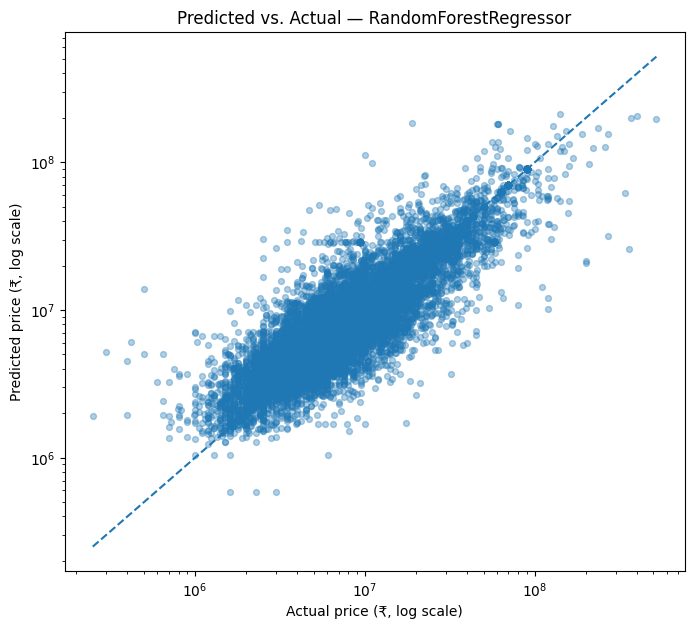

Winner: RandomForestRegressor
The winning model is selected based primarily on the highest test R², while MAE and RMSE are also considered. This keeps the model choice tied to unseen test-set performance rather than training performance.


In [ ]:
winner_name = results_df.loc[0, "Model"]
winner_model = trained_models[winner_name]
winner_pred = winner_model.predict(X_test)

plt.figure(figsize=(8, 7))
plt.scatter(y_test, winner_pred, alpha=0.35, s=18)
lims = [min(y_test.min(), winner_pred.min()), max(y_test.max(), winner_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual price (₹, log scale)")
plt.ylabel("Predicted price (₹, log scale)")
plt.title(f"Predicted vs. Actual — {winner_name}")
plt.show()

print(f"Winner: {winner_name}")
print("The winning model is selected based primarily on the highest test R², while MAE and RMSE are also considered. This keeps the model choice tied to unseen test-set performance rather than training performance.")

## 2.6 Export the Model

Export the complete winning pipeline so preprocessing is preserved with the model. Also export the allowed location list for future use.

In [ ]:
# Save model and allowed locations
joblib.dump(winner_model, "house_price.pkl")
json.dump(
    sorted(X["location_grouped"].dropna().unique().tolist()),
    open("locations.json", "w")
)

# Sanity check: reload and predict one test sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))
print("Saved: house_price.pkl")
print("Saved: locations.json")

Reloaded prediction: [8370201.76739927]
Saved: house_price.pkl
Saved: locations.json


## Final Conclusion

The notebook completes the requested Machine Learning workflow: data inspection, target/area parsing, exploratory analysis, feature engineering, missing-value handling through a preprocessing pipeline, location grouping, outlier filtering, training of at least two regression models, test-set evaluation using MAE/RMSE/R², predicted-vs-actual visualization, model comparison, and export of the selected pipeline.

**Backend note:** I have not worked on the Backend before, so Backend/FastAPI implementation is intentionally outside the scope of this notebook. As a result, the Frontend implementation and full end-to-end integration could not be completed.